# Sistema de prediccion de ventas

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
import itertools
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
#import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Cargamos el data set
ruta = r"../data/raw/sales.csv"
df = pd.read_csv(ruta, sep=",")

In [3]:
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [4]:
df.dtypes

date      object
sales    float64
dtype: object

In [5]:
df.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


In [6]:
df.isnull().sum()

date     0
sales    0
dtype: int64

## Convertimos la columna date y agrupamos ventas

In [7]:
df['date'] = pd.to_datetime(df['date'])  # Asegurar formato de fecha
ventas_por_fecha = df.groupby('date')['sales'].sum()

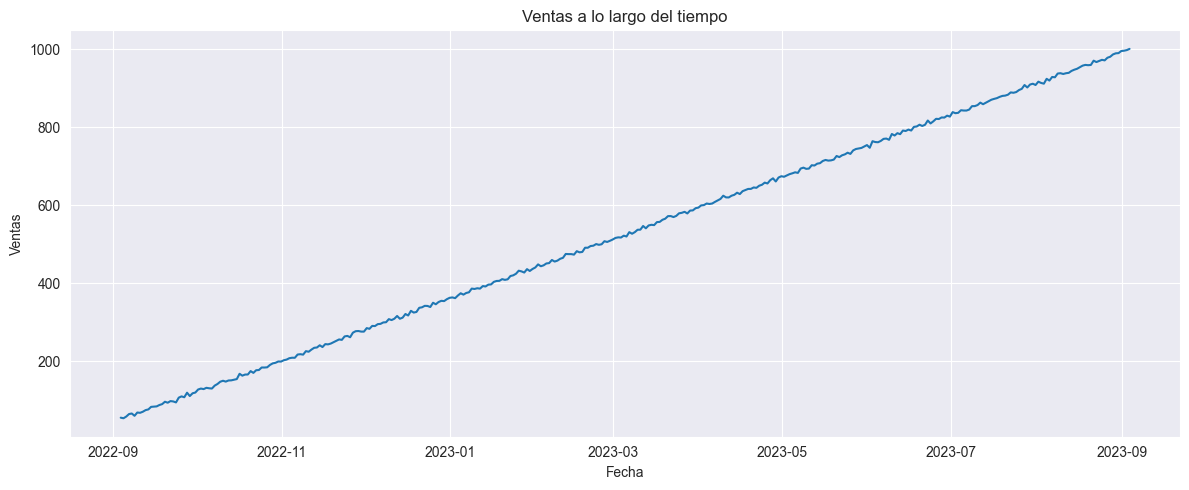

In [8]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=ventas_por_fecha.index, y=ventas_por_fecha.values)
plt.title("Ventas a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

# Descomposicion de la serie temporal

In [9]:
# Convertir 'date' a datetime y poner como índice
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [10]:
# Rellenar fechas faltantes con frecuencia diaria
df = df.asfreq('D')

In [11]:
# Rellenar valores vacíos con interpolación
df['sales'] = df['sales'].interpolate()

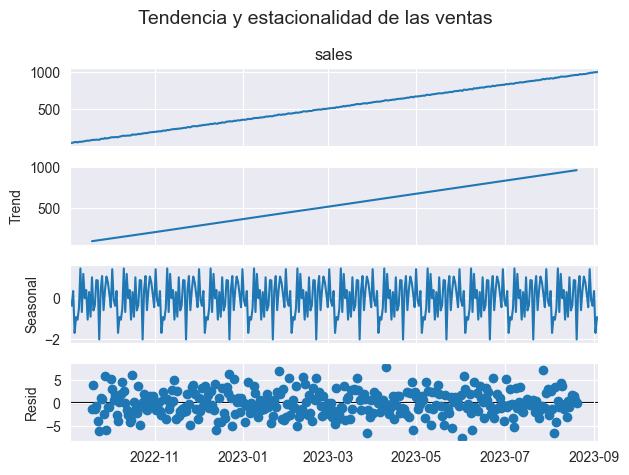

In [12]:
# Descomponer la serie (estacionalidad mensual aprox = 30 días)
result = seasonal_decompose(df['sales'], model='additive', period=30)
result.plot()
plt.suptitle('Tendencia y estacionalidad de las ventas', fontsize=14)
plt.tight_layout()
plt.show()

### Ejercicio `¿Cual es el tensor de la serie temporal?`:
> - Aquí la serie temporal es unidimensional (una sola variable: sales) indexada por fechas (índice temporal). Es decir, la estructura es un vector 1D (serie temporal) con una dimensión temporal.
> - Por lo tanto, podríamos decir que el tensor es de forma (n,), donde n es el número total de días en la serie.

In [13]:
f"la serie tiene {df.shape[0]} datos (dias)."

'la serie tiene 366 datos (dias).'

## Ejercicio `¿Cual es la tendencia?`:
> - Para calcular la tendencia usamos la descomposicion ya vista:

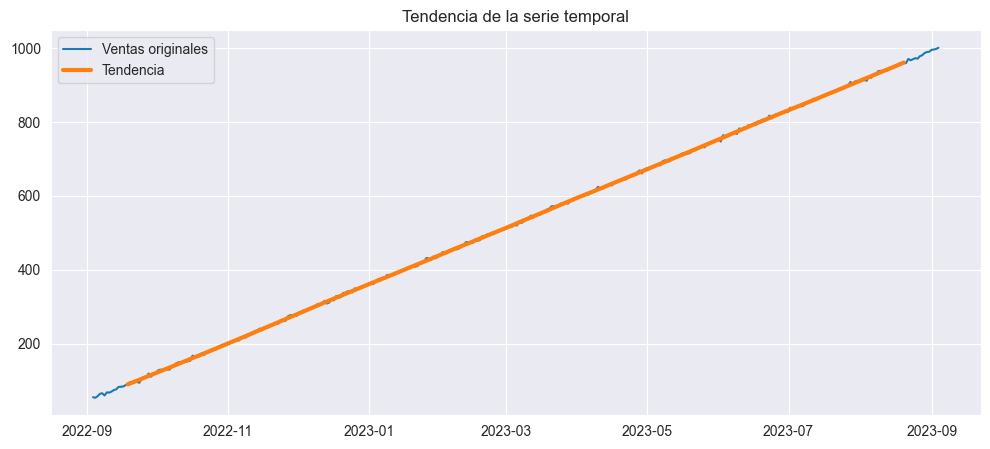

In [14]:
result = seasonal_decompose(df['sales'], model='additive', period=30)

# Graficar tendencia
plt.figure(figsize=(12,5))
plt.plot(df.index, df['sales'], label='Ventas originales')
plt.plot(result.trend, label='Tendencia', linewidth=3)
plt.title('Tendencia de la serie temporal')
plt.legend()
plt.show()

### Ejercicio `¿Es estacionaria?`:
> - Como sabemos si es estacionaria o no?:

In [15]:
adf_result = adfuller(df['sales'].dropna())
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

if adf_result[1] < 0.05:
    print("La serie es estacionaria (rechazamos H0 de raíz unitaria).")
else:
    print("La serie NO es estacionaria (no rechazamos H0).")

ADF Statistic: 0.545414193706381
p-value: 0.9861899815311065
La serie NO es estacionaria (no rechazamos H0).


## Ejercicio `¿Existe variabilidad o presencia de ruido?`:
> - Sí, hay fluctuaciones y un componente residual que indica presencia de ruido.

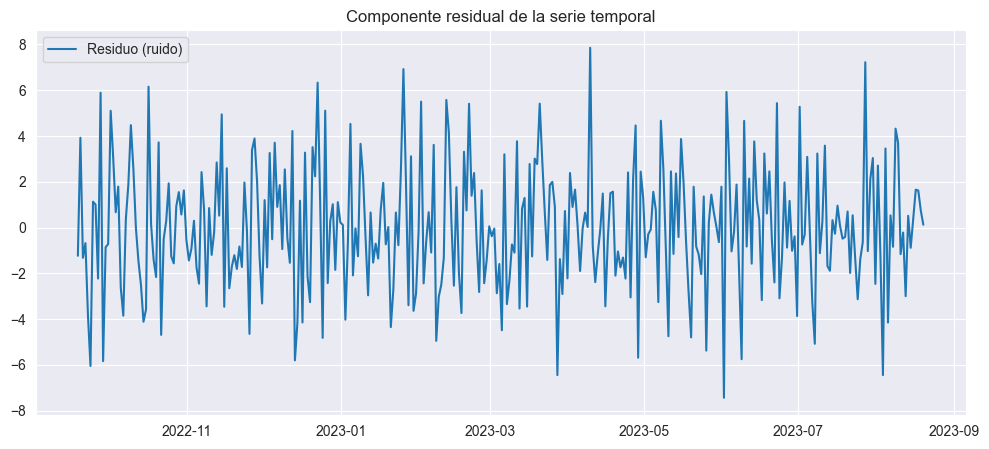

Descripción estadística del residuo:
count    336.000000
mean      -0.007386
std        2.721021
min       -7.438134
25%       -1.725124
50%       -0.177342
75%        1.852219
max        7.852585
Name: resid, dtype: float64


In [16]:
plt.figure(figsize=(12,5))
plt.plot(result.resid, label='Residuo (ruido)')
plt.title('Componente residual de la serie temporal')
plt.legend()
plt.show()

print("Descripción estadística del residuo:")
print(result.resid.describe())

## Separamos los datos en entranamiento y prueba

In [17]:
# Dividir datos (80% entrenamiento, 20% prueba)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]['sales']
test = df.iloc[train_size:]['sales']

## Buscamos la mejor parametrizacion de ARIMA
>> - No podemos implementar la manera automatica porque no soporta el sistema; intente buscar el modelo de busqueda automatica, pero no pude implementarla, entonces busque la manera de buscar la mejor parametrizacion manualmente.

In [ ]:
# Encontrar mejor modelo ARIMA automáticamente
#modelo_auto = pm.auto_arima(train, seasonal=False, stepwise=True, trace=True,
#                          error_action='ignore', suppress_warnings=True,
#                           max_p=5, max_q=5, max_d=2)

#modelo_auto.summary()

### Esta es la forma de busqueda de parametros manualmente

In [19]:
# Define rangos para p, d, q
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

warnings.filterwarnings("ignore")

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        result = model.fit()
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order
    except:
        continue

print("Mejor orden (p,d,q):", best_order)

Mejor orden (p,d,q): (2, 0, 2)


## Entrenamos el moedlo ARIMA con los parametros seleccionado

In [20]:
# Entrenar modelo ARIMA con los mejores parámetros
p, d, q = best_order
arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()

# Mostrar resumen
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(2, 0, 2)   Log Likelihood                   0.000
Date:                Fri, 18 Jul 2025   AIC                             12.000
Time:                        10:33:44   BIC                             34.061
Sample:                    09-03-2022   HQIC                            20.837
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        436.2568   9.83e-08   4.44e+09      0.000     436.257     436.257
ar.L1          2.0000    4.7e-07   4.25e+06      0.000       2.000       2.000
ar.L2         -1.0000   1.91e-08  -5.22e+07      0.000      -1.000      -1.000
ma.L1         -1.9313      0.025    -76.498      0.000      -1.981      -1.882
ma.L2          0.9314      0.025     36.902      0.000       0.882       0.981
sigma2         8.9903      0.000   7.02e+04      0.000       8.990       8.991
===================================================================================
Ljung-Box (L1) (Q):                    nan   Jarque-Bera (JB):                  nan
Prob(Q):                               nan   Prob(JB):                          nan
Heteroskedasticity (H):                nan   Skew:                              nan
Prob(H) (two-sided):                   nan   Kurtosis:                          nan
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.9e+23. Standard errors may be unstable.
"""

## Evaluamos desempeño y hacemos predicciones

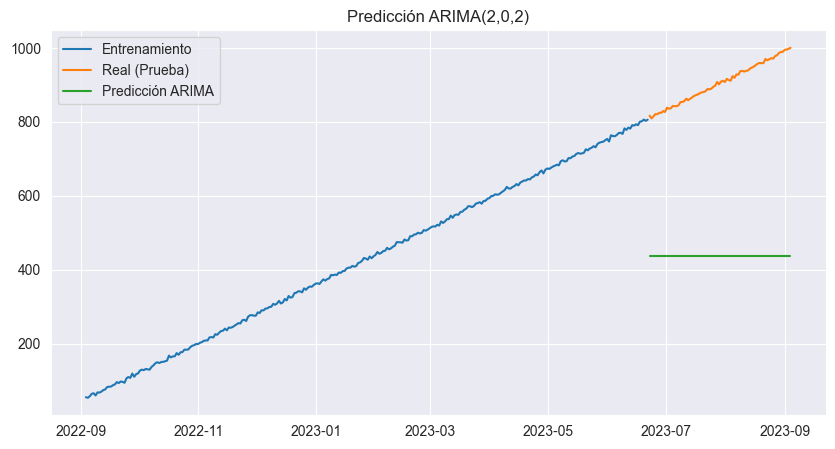

In [21]:
# Predicciones
pred = arima_result.forecast(steps=len(test))

# visualizamos
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Real (Prueba)')
plt.plot(test.index, pred, label='Predicción ARIMA')
plt.legend()
plt.title(f'Predicción ARIMA({p},{d},{q})')
plt.show()

In [22]:
# Evaluar rendimiento
rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


RMSE: 471.62
MAE: 468.35


### Guardamos los archivos

In [23]:
# Guardar datasets
train.to_csv(r'../data/processed/train_sales.csv')
test.to_csv(r'../data/processed/test_sales.csv')

# Guardar modelos
joblib.dump(result, '../models/seasonal_decompose_result.joblib')
joblib.dump(best_order, '../models/best_order.joblib')
joblib.dump(arima_result, '../models/arima_model.joblib')

['../models/arima_model.joblib']